# Name : Krishna lund
# Cms-ID : 023-24-0271
# ML-Lab Assigment-03
# Section-H
# Github Profile: https://github.com/Krishnalund/telco-customer-churn-eda
# Kaggle Profile: https://www.kaggle.com/krishnalund18
# Dataset: Telco Customer Churn
# Dataset sourse: https://www.kaggle.com/datasets/vedatgul/telco-churn-dataset

# Part 1 — Problem Definition & Dataset Verification

In [3]:
#Task-01 Load clean_churn.csv (or re-run your Lab 2 cleaning). Verify its shape, column dtypes, and that there are no
# missing values remaining.

#Explanation: The dataset was checked for missing values, and no missing values were found. Therefore, the dataset is ready for feature preparation.

import pandas as pd 
df = pd.read_csv("clean_churn.csv")
print("Shape: ",df.shape)
print("Colums' datatypes: ",df.dtypes)
print("Missing values: ",df.isnull().sum())


Shape:  (7021, 20)
Colums' datatypes:  gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object
Missing values:  gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod     

In [ ]:
# Task-02 In 1–2 sentences, restate the ML problem: what exactly are you predicting, and why does it matter to the business?

# Explanation: The goal is to predict whether a telecom customer will churn based on their demographic information, services, contract, and billing details. 
# This prediction is important because it can help the company identify customers who are likely to leave and take actions to reduce customer loss.

# Part 2 — Feature & Target Preparation


In [4]:
# Task-03 Define y as the Churn column, encoded as 0/1. Define X as the remaining relevant columns — drop any identifier column still present
# Explanation : The churn columns is used as the target variable y where No is encoded as 0 and Yes is encoded as 1. All other relevant columns
#               are stored in X and will be used as input features to predict that whether a customer will churn.

y =  df["Churn"].map({'No': 0, 'Yes': 1}) 
X = df.drop(columns = ["Churn"])
print("X shape: ",X.shape)
print("y shape: ", y.shape)
print("\ny values: ")
print(y.value_counts())

X shape:  (7021, 19)
y shape:  (7021,)

y values: 
Churn
0    5164
1    1857
Name: count, dtype: int64


In [5]:
# Task-04 Convert every remaining categorical column in X into numeric form. Briefly justify your choice of encoding
# method (e.g. one-hot vs. manual mapping).

# Explanation: Converted categorical columns to numeric columns using one-hot encoding and [drop_first=True] drops one category from each feature.
#              If all dummy columns for a feature contain 0, it means the customer belongs to the dropped category.

X = pd.get_dummies(X, drop_first = True , dtype=int)
print(X.head())
print(X.dtypes)

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85            0   
1              0      34           56.95       1889.50            1   
2              0       2           53.85        108.15            1   
3              0      45           42.30       1840.75            1   
4              0       2           70.70        151.65            0   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0            1               0                 0   
1            0               0                 1   
2            0               0                 1   
3            0               0                 0   
4            0               0                 1   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0                               1                  0  ...   
1                               0                  0  ...   
2                               0                  0  ...   
3               

In [6]:
# Task-05 Confirm X contains only numeric columns and has no missing values before moving on.
# Explanation: Found that X contains only numeric columns using X.dtypes and found that there are no null values using isnull().sum().

X.dtypes
X.isnull().sum()

SeniorCitizen                            0
tenure                                   0
MonthlyCharges                           0
TotalCharges                             0
gender_Male                              0
Partner_Yes                              0
Dependents_Yes                           0
PhoneService_Yes                         0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV_Yes                          0
StreamingMovies_No internet service      0
StreamingMo

# Part 3 — Train/Test Split


In [2]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.3 MB 2.5 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.3 MB 4.9 MB/s eta 0:00:02
   ------------------ --------------------- 3.9/8.3 MB 6.4 MB/s eta 0:00:01
   --------------------------- ------------ 5.8/8.3 MB 6.3 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 8.1 MB/s  0:00:01
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   -- ------------------------------------- 2.1/37.4 MB 11.1 MB/s eta 0:00:04
   ----- ---------------------------------- 4.7/37.4 MB 11.4 MB/s eta 0:00:03
   ----- ---------------------------------- 5.5/37.4 MB 8.9 MB/s eta 0:00:04
   ------- -------------------------------- 6.8/37.4 MB 8.8 MB/s eta 0:00:04
   -------- ------------------------------- 8.4/37.4 MB 7.8 MB/s eta 0:00:04
   ------------ ------------

In [7]:
# Task-06 Split X and y into training and test sets (e.g. an 80/20 split). Why is stratify=y a sensible choice, given what you
# found about the target's class balance in Lab 2?

#Explanation: stratify=y is sensible because the Churn target is imbalanced. In lab 2, about 73.46% of customers did not churn and
# 26.54% churned. Using stratify=y helps keep approximately the same proportion of churned and non=churned customers in both
# the training and testing sets.

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (5616, 30)
Testing set size: (1405, 30)


In [8]:
# Task-07 Report the shape of X_train, X_test, y_train, and y_test

# Explanation: The training set contains 5616 samples, while the testing set contains 1405 samples. X has 30 input features, 
# while y contains only the target value (Churn) for each customer.

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5616, 30)
X_test shape: (1405, 30)
y_train shape: (5616,)
y_test shape: (1405,)


# Part 4 — Baseline Decision Tree

In [9]:
# Task-08 Train a DecisionTreeClassifier on the training data with default settings (only random_state fixed). Generate
# predictions on both the training and test sets.

# Explanation: The decision tree is trained using X_train and y_train. Then, predictions are generated for both the training
# set (y_train_pred) and the testing set (y_test_pred).
# y_train_pred --> predictions for training data
# y_test_pred --> predictions for test data
# random_state=42 --> ensures the results are reproducible (It means when run the same code again,we should get the same results.)

from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [10]:
# Task-09 What depth did scikit-learn actually grow this tree to on its own? Does that surprise you?

# Explanation: No, it is not surprising because we used the Decision Tree with its default settings and did not set a maximum depth.
# Therefore, the tree was allowed to keep growing until scikit-learn's stopping conditions were reached. A depth of 26 is relatively
# deep and may indicate that the model is fitting the training data very closely, which could lead to overfitting.
print("Actual tree depth:", model.get_depth())

Actual tree depth: 26


# Part 5 — Model Evaluation

In [11]:
# Task-10 Compute accuracy, precision, recall, and F1-score on the test set. Report them in a small table.

# Explanation: The model has an accuracy of about 72.24%, but its precision, recall, and F1-score for predicting churn are around
# 48-50%. This suggests that although the overall accuracy looks reasonable, the model is less effective at correctly identifying
# churned customers, which is important because the dataset has an imbalanced target.

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [accuracy, precision, recall, f1]
})
print(results)

      Metric     Score
0   Accuracy  0.722420
1  Precision  0.476804
2     Recall  0.497312
3   F1-score  0.486842


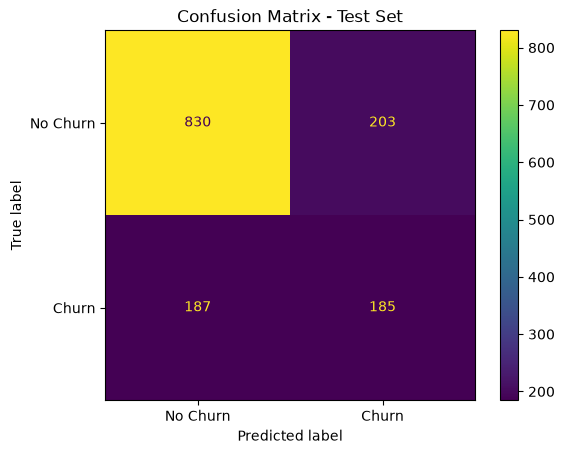

Confusion Matrix:
[[830 203]
 [187 185]]


In [12]:
# Task-11 Plot the confusion matrix for the test set. How many actual churners did the model correctly catch, and how many did it miss?

# Explanation: The model correctly identified 185 actual churners, but it missed 187 churners by predicting that they would not churn.
# This shows that the model has difficulty identifying churned customers.

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_test_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

display.plot()
plt.title("Confusion Matrix - Test Set")
plt.show()
print("Confusion Matrix:")
print(cm)

In [ ]:
# Task-12 Given Lab 2's finding about class imbalance, which metric(s) do you trust most for this problem, and why?

# Explanation: Given the class imbalance, I would trust precision, recall, and F1-score more than accuracy. Accuracy can look high
# because most customers do not churn, while recall shows how many actual churners the model correctly identifies, which is important
# for this problem.

# Part 6 — Overfitting Investigation

In [13]:
# Task-13 Compare your baseline tree's accuracy on the training set vs. the test set. Is there a large gap? What does that
# suggest about the model?

# Explanation: Yes, there is a large gap between training and test accuracy. This strongly suggests that the Decision Tree is
# overfitting, meaning it learned the training data very well but does not perform well on unseen test data.

from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Training Accuracy: 0.9976851851851852
Test Accuracy: 0.7224199288256228


In [14]:
# Task-14 Train several Decision Trees at different max_depth values (e.g. 2, 3, 4, 5, 6, 8, 10, and unrestricted). Record
# train accuracy and test accuracy for each in a results table.

# Explanation: The results show that training accuracy generally increases as the tree depth increases. 
# Test accuracy improves until approximately depth 5, where it reaches its highest value. After depth 5, training accuracy continues to increase 
# while test accuracy starts decreasing, indicating that the model begins to overfit.

depths = [2, 3, 4, 5, 6, 8, 10, None]

results = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)

    results.append({
        "max_depth": depth,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy
    })

results_df = pd.DataFrame(results)

print(results_df)

   max_depth  Train Accuracy  Test Accuracy
0        2.0        0.792201       0.783630
1        3.0        0.792201       0.783630
2        4.0        0.795228       0.784342
3        5.0        0.801816       0.787189
4        6.0        0.808226       0.785053
5        8.0        0.835470       0.778648
6       10.0        0.869124       0.770107
7        NaN        0.997685       0.722420


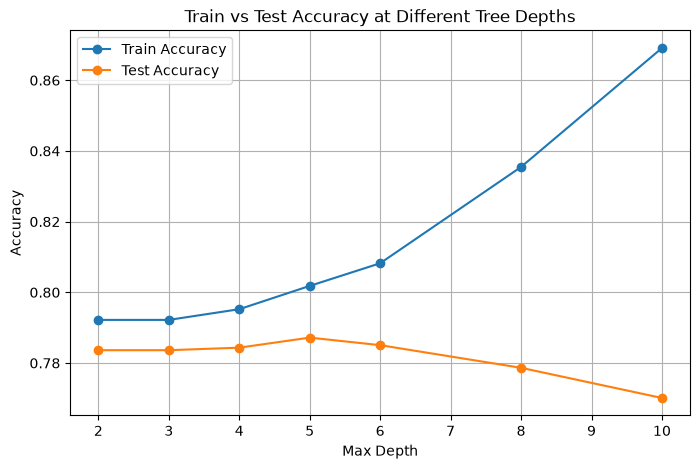

In [15]:
# Task-15 Plot train accuracy and test accuracy against max_depth on the same chart. At roughly what depth does the
# model start to overfit? Explain how the chart shows this.

# Explanation: The graph shows that training accuracy continues to increase as the tree becomes deeper.
# Test accuracy reaches its highest point around depth 5 and then begins to decrease. 
# This growing difference between training and test accuracy suggests that deeper trees are overfitting the training data.

plot_df = results_df.copy()
plot_df["Depth"] = plot_df["max_depth"].replace({None: 12})

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df["Depth"],
    plot_df["Train Accuracy"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    plot_df["Depth"],
    plot_df["Test Accuracy"],
    marker="o",
    label="Test Accuracy"
)

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy at Different Tree Depths")

plt.legend()
plt.grid()

plt.show()


# Part 7 — Model Selection, Feature Importance & Interpretation

In [ ]:
# Task-16 Based on your Part 6 table/plot, select a max_depth you consider the best model. Justify your choice in 2–3
# sentences — it should not simply be the depth with the highest training accuracy.

# Explanation: I selected max_depth = 5 as the best model because it achieved the highest test accuracy among the tested depths while maintaining
# a relatively small difference between training and test accuracy. Deeper trees achieved higher training accuracy but lower test accuracy, 
# which indicates increased overfitting. Therefore, depth 5 provides a better balance between model performance and complexity.


      Metric  Best Model (Depth 5)
0   Accuracy              0.787189
1  Precision              0.651452
2     Recall              0.422043
3   F1-Score              0.512235


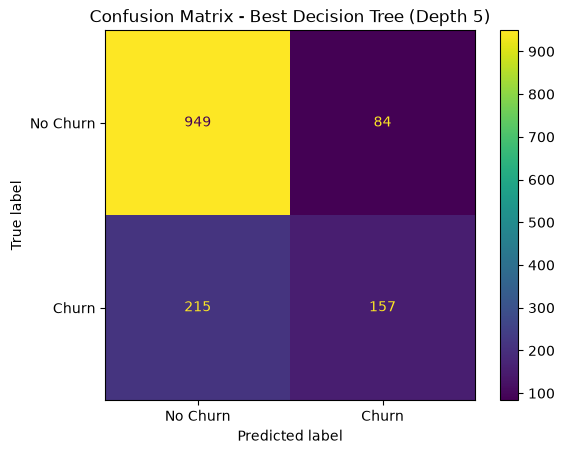

In [16]:
# Task-17 Retrain a Decision Tree at your chosen depth and report its full evaluation metrics (as in Part 5) for comparison
# against the baseline.

# Explanation: The Decision Tree with max_depth = 5 achieved an accuracy of 0.787. Its precision was 0.651, recall was 0.422, and F1-score was 0.512. 
# Compared with the unrestricted baseline model, the depth-limited model provides better generalization and reduces overfitting.

import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
dt_best = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_best.fit(X_train, y_train)

y_pred_best = dt_best.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)

best_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Best Model (Depth 5)": [
        accuracy_best,
        precision_best,
        recall_best,
        f1_best
    ]
})

print(best_results)
cm_best = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("Confusion Matrix - Best Decision Tree (Depth 5)")

plt.show()

      Metric  Entropy (Depth 5)
0   Accuracy           0.787900
1  Precision           0.627586
2     Recall           0.489247
3   F1-Score           0.549849


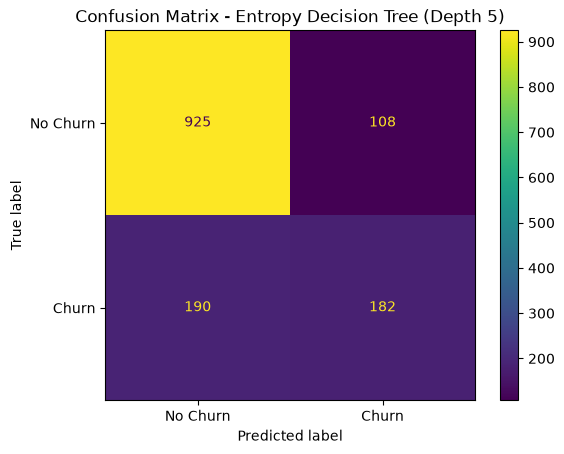

In [20]:
# Task-18 Retrain a Decision Tree with “entropy” as the splitting criterion rather than the default (“gini”) and report its
# full evaluation metrics (as in Part 5) for comparison against the baseline.

# Explanation: Compared to the Gini-based model (Accuracy 0.787, Precision 0.651, Recall 0.422, F1 0.512),
# the entropy-based model achieves similar accuracy (0.788) and slightly lower precision (0.628), but a
# meaningfully higher recall (0.489 vs 0.422) and F1-score (0.550 vs 0.512). Since Part 5 established that
# recall/F1 matter more than raw accuracy for this imbalanced churn problem, the entropy criterion is the
# better choice, it identifies more true churners with only a modest precision trade-off.

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import pandas as pd
import matplotlib.pyplot as plt

dt_entropy = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    random_state=42
)

dt_entropy.fit(X_train, y_train)
y_pred_entropy = dt_entropy.predict(X_test)

accuracy_entropy = accuracy_score(y_test, y_pred_entropy)
precision_entropy = precision_score(y_test, y_pred_entropy)
recall_entropy = recall_score(y_test, y_pred_entropy)
f1_entropy = f1_score(y_test, y_pred_entropy)

entropy_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Entropy (Depth 5)": [
        accuracy_entropy,
        precision_entropy,
        recall_entropy,
        f1_entropy
    ]
})

print(entropy_results)
cm_entropy = confusion_matrix(y_test, y_pred_entropy)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_entropy,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Entropy Decision Tree (Depth 5)")
plt.show()


Feature Importances:
                                  Feature  Importance
1                                  tenure    0.435296
10            InternetService_Fiber optic    0.356418
3                            TotalCharges    0.046020
24                      Contract_One year    0.025760
2                          MonthlyCharges    0.025629
12     OnlineSecurity_No internet service    0.022843
28         PaymentMethod_Electronic check    0.019030
22    StreamingMovies_No internet service    0.018688
25                      Contract_Two year    0.017729
9                       MultipleLines_Yes    0.014167
7                        PhoneService_Yes    0.007257
19                        TechSupport_Yes    0.004792
27  PaymentMethod_Credit card (automatic)    0.002416
0                           SeniorCitizen    0.002411
5                             Partner_Yes    0.001543
13                     OnlineSecurity_Yes    0.000000
6                          Dependents_Yes    0.000000
8      

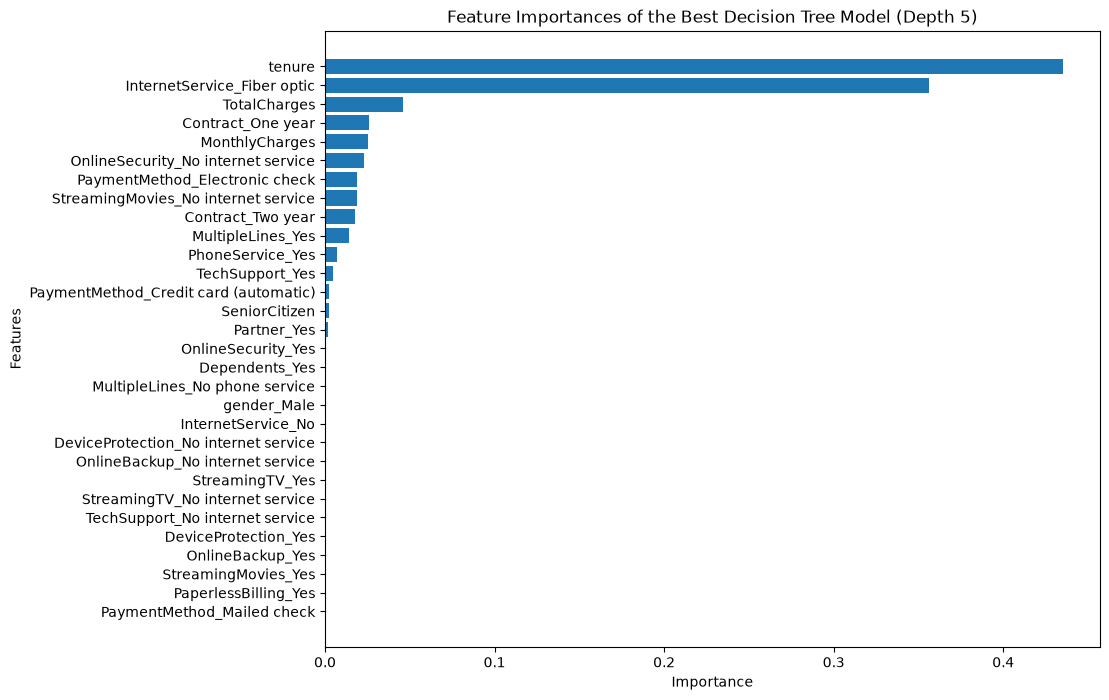

In [21]:
# Task-19 Extract and visualize feature_importances_ for your chosen model. Which 3–5 features matter most?

# Explanation: The five most important features for predicting customer churn are tenure, InternetService_Fiber optic, TotalCharges, 
# Contract_One year, and MonthlyCharges. Tenure and InternetService_Fiber optic have the highest importance, showing that the length 
# of time a customer has stayed with the company and whether they use Fiber optic internet strongly influence the model's churn predictions. 
# TotalCharges, contract type, and MonthlyCharges also contribute to predicting customer churn.

import pandas as pd
import matplotlib.pyplot as plt

importances = dt_best.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
})
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importances:")
print(feature_importance_df)

print("\nTop 5 Most Important Features:")
print(feature_importance_df.head(5))

plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importances of the Best Decision Tree Model (Depth 5)")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
# Task-20 In 2–3 sentences, connect the top features to what you already found in Lab 2's EDA — do they agree with the
# patterns you saw then?

# Explanation: The feature importance results generally agree with the patterns observed during the Lab 2 EDA. 
# Tenure, InternetService, contract type, and charges showed meaningful relationships with customer churn. 
# The Decision Tree also identified these factors as important, suggesting that customer duration, internet service type, 
# contract information, and billing charges are useful for predicting whether a customer will churn.

# Part 8 — Conclusion & Next Steps

In [ ]:
# Task-21 Write a short conclusion (4–6 sentences): which model did you land on, how well does it perform, and what are
# its main limitations?

# Explanation: In this lab, I trained and evaluated Decision Tree models to predict customer churn. After testing different tree depths, 
# I selected the Decision Tree with a maximum depth of 5 because it achieved the best balance between model performance and complexity. 
# The selected model achieved an accuracy of 78.72%, precision of 65.15%, recall of 42.20%, and an F1-score of 51.22%. Limiting the 
# tree depth helped reduce overfitting compared with the unrestricted baseline model. However, the model still has limitations, particularly 
# its relatively low recall, which means that some customers who are likely to churn may not be correctly identified.

In [ ]:
#Task-22 What would you try next if you had more time (e.g. a different algorithm, more feature engineering, handling
# class imbalance)? Describe it — do not implement it here.

# Explanation: If I had more time, I would try algorithms such as Random Forest or Logistic Regression and compare their
# performance with the Decision Tree. I would also handle the class imbalance using some techniques to improve churn detection.
# and may try feature engineering to create more useful features such as TotalServices, AverageMonthlySpend, TenureGroup to imporve
# the model's performance.

In [5]:
#Task-23 Implement ID3 from scratch on the Play Badminton dataset from class. No built-in decision tree libraries —
# write your own entropy and information gain functions. Print the gain values for each attribute at every split.

# Explanation: The ID3 algorithm was implemented from scratch using custom entropy and information gain functions.
# At each split, the information gain of all remaining attributes was calculated and printed, and the attribute 
# with the highest gain was selected as the splitting node. 
# The algorithm continued recursively until all records in a branch belonged to the same class.

import pandas as pd
import math
data = {
    "Outlook": [
        "Sunny", "Sunny", "Overcast", "Rain", "Rain",
        "Rain", "Overcast", "Sunny", "Sunny", "Rain",
        "Sunny", "Overcast", "Overcast", "Rain"
    ],

    "Temperature": [
        "Hot", "Hot", "Hot", "Mild", "Cool",
        "Cool", "Cool", "Mild", "Cool", "Mild",
        "Mild", "Mild", "Hot", "Mild"
    ],

    "Humidity": [
        "High", "High", "High", "High", "Normal",
        "Normal", "Normal", "High", "Normal", "Normal",
        "Normal", "High", "Normal", "High"
    ],

    "Wind": [
        "Weak", "Strong", "Weak", "Weak", "Weak",
        "Strong", "Strong", "Weak", "Weak", "Weak",
        "Strong", "Strong", "Weak", "Strong"
    ],

    "Play": [
        "No", "No", "Yes", "Yes", "Yes",
        "No", "Yes", "No", "Yes", "Yes",
        "Yes", "Yes", "Yes", "No"
    ]
}

df = pd.DataFrame(data)

print(df)


     Outlook Temperature Humidity    Wind Play
0      Sunny         Hot     High    Weak   No
1      Sunny         Hot     High  Strong   No
2   Overcast         Hot     High    Weak  Yes
3       Rain        Mild     High    Weak  Yes
4       Rain        Cool   Normal    Weak  Yes
5       Rain        Cool   Normal  Strong   No
6   Overcast        Cool   Normal  Strong  Yes
7      Sunny        Mild     High    Weak   No
8      Sunny        Cool   Normal    Weak  Yes
9       Rain        Mild   Normal    Weak  Yes
10     Sunny        Mild   Normal  Strong  Yes
11  Overcast        Mild     High  Strong  Yes
12  Overcast         Hot   Normal    Weak  Yes
13      Rain        Mild     High  Strong   No


In [6]:
def entropy(data, target="Play"):

    counts = data[target].value_counts()

    total = len(data)

    entropy_value = 0

    for count in counts:

        probability = count / total

        entropy_value -= probability * math.log2(probability)

    return entropy_value

In [7]:
def information_gain(data, attribute, target="Play"):

    total_entropy = entropy(data, target)

    weighted_entropy = 0

    total = len(data)

    for value in data[attribute].unique():

        subset = data[data[attribute] == value]

        probability = len(subset) / total

        weighted_entropy += probability * entropy(subset, target)

    gain = total_entropy - weighted_entropy

    return gain

In [8]:
def best_attribute(data, attributes, target="Play"):

    gains = {}

    print("\nInformation Gain Values:")

    for attribute in attributes:

        gain = information_gain(data, attribute, target)

        gains[attribute] = gain

        print(attribute, "=", round(gain, 4))

    best = max(gains, key=gains.get)

    print("Best Attribute:", best)

    return best

In [9]:
def id3(data, attributes, target="Play", depth=0):

    indent = "  " * depth

    if len(data[target].unique()) == 1:

        return data[target].iloc[0]

    if len(attributes) == 0:

        return data[target].mode()[0]

    print("\n" + indent + "Current Split")
    print(indent + "Entropy =", round(entropy(data, target), 4))

    best = best_attribute(data, attributes, target)

    tree = {best: {}}

    remaining_attributes = [
        attribute for attribute in attributes
        if attribute != best
    ]

    for value in data[best].unique():

        print("\n" + indent + best + " =", value)

        subset = data[data[best] == value]

        if len(subset) == 0:

            tree[best][value] = data[target].mode()[0]

        else:

            tree[best][value] = id3(
                subset,
                remaining_attributes,
                target,
                depth + 1
            )

    return tree

In [10]:
attributes = [
    "Outlook",
    "Temperature",
    "Humidity",
    "Wind"
]

tree = id3(df, attributes)

print("\nFinal Decision Tree:")
print(tree)


Current Split
Entropy = 0.9403

Information Gain Values:
Outlook = 0.2467
Temperature = 0.0292
Humidity = 0.1518
Wind = 0.0481
Best Attribute: Outlook

Outlook = Sunny

  Current Split
  Entropy = 0.971

Information Gain Values:
Temperature = 0.571
Humidity = 0.971
Wind = 0.02
Best Attribute: Humidity

  Humidity = High

  Humidity = Normal

Outlook = Overcast

Outlook = Rain

  Current Split
  Entropy = 0.971

Information Gain Values:
Temperature = 0.02
Humidity = 0.02
Wind = 0.971
Best Attribute: Wind

  Wind = Weak

  Wind = Strong

Final Decision Tree:
{'Outlook': {'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}, 'Overcast': 'Yes', 'Rain': {'Wind': {'Weak': 'Yes', 'Strong': 'No'}}}}


 # ✅ Final Submission Checklist

- [Done] Student Information Block completed
- [Done] All 11 required notebook sections included
- [Done] Dataset prepared and Train/Test Split completed
- [Done] Baseline Decision Tree trained and evaluated
- [Done] Accuracy, Precision, Recall, F1-score & Confusion Matrix included
- [Done] Overfitting experiment with multiple max_depth values, table & graph
- [Done] Best model selected and justified + Entropy comparison
- [Done] Feature Importance graph and interpretation included
- [Done] ID3 implemented from scratch with Entropy & Information Gain
- [Done] Conclusion, Next Steps, and written interpretations included